In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import nltk
from nltk.corpus import stopwords

import plotly.graph_objects as go
from sklearn.manifold import TSNE
from wordcloud import WordCloud

try:
    _ = stopwords.words("english")
except LookupError:
    nltk.download("stopwords", quiet=True)

import src.advanced_feature_extraction as afe
importlib.reload(afe)
from src.advanced_feature_extraction import build_nlp_features_train

In [2]:
project_root = Path.cwd().parent

data_dir = project_root / "data"
raw_dir = data_dir / "raw"
processed_dir = data_dir / "processed"

notebooks_dir = project_root / "notebooks"

reports_dir = project_root / "reports"

train_zip_path = raw_dir / "quora_question_pairs_train.csv.zip"
test_zip_path = raw_dir / "quora_question_pairs_test.csv.zip"

train_csv_path = raw_dir / "train.csv"
test_csv_path = raw_dir / "test.csv"

df_fe_train_path = processed_dir / "df_fe_without_preprocessing_train.csv"
nlp_features_train_path = processed_dir / "nlp_features_train.csv"

tsne_3d_html_path = reports_dir / "tsne_3d_engineered_features.html"

processed_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)


# Business Problem

Many digital platforms contain large amounts of user-generated or system-generated textual data, such as product listings, customer requests, support tickets, and search queries. A common issue in such systems is the presence of duplicate or semantically equivalent entries that are phrased differently.

These duplicates create several business problems:
- They increase storage and processing costs.
- They reduce the quality of search, recommendation, and analytics systems.
- They make it harder for users and employees to find relevant information.
- They lead to fragmented statistics and duplicated work (e.g., multiple responses to the same request).

The business goal of this project is to automatically detect whether two given questions have the same meaning, even if they are worded differently. This is formulated as a binary classification problem where the system predicts the probability that a pair of questions is a duplicate.

An accurate duplicate detection system can be used in multiple real-world scenarios, such as:
- Identifying duplicate customer inquiries in support systems.
- Detecting similar product names or descriptions on marketplaces.
- Removing redundant entries in internal knowledge bases or databases.
- Improving search and recommendation systems by grouping equivalent content.

By solving this problem, the business can improve data quality, reduce operational costs, and enhance user experience by minimizing redundancy and ensuring consistent handling of similar content.


# Exploratory Data Analysis

## Reading data and basic stats

In [3]:
df = pd.read_csv(train_zip_path)
print(df.isna().sum())

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


In [4]:
df = df.dropna()

print("Number of data points:",df.shape[0])

Number of data points: 323429


In [5]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0
1,196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0
2,113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0
3,266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0
4,122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 323429 entries, 0 to 323431
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            323429 non-null  int64 
 1   qid1          323429 non-null  int64 
 2   qid2          323429 non-null  int64 
 3   question1     323429 non-null  object
 4   question2     323429 non-null  object
 5   is_duplicate  323429 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 17.3+ MB


## Distribution of data points among output classes

<Axes: xlabel='is_duplicate'>

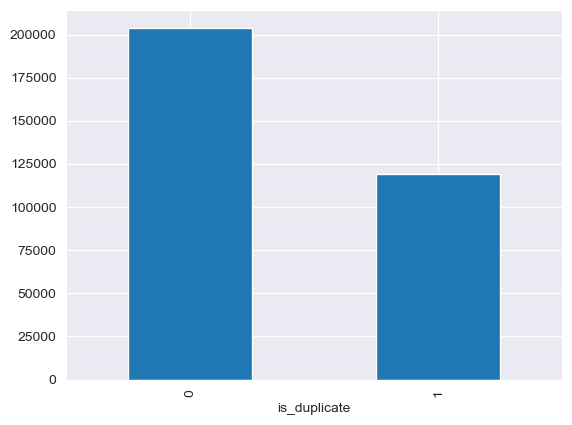

In [7]:
df.groupby("is_duplicate")['id'].count().plot.bar()

In [8]:
total_pairs = len(df)

class_counts = df['is_duplicate'].value_counts().sort_index()
percentages = class_counts / total_pairs * 100

print(f"Total number of question pairs for training:\n   {total_pairs}")
print(f"Question pairs are not Similar (is_duplicate = 0):\n   {percentages.get(0, 0):.2f}%")
print(f"Question pairs are Similar (is_duplicate = 1):\n   {percentages.get(1, 0):.2f}%")


Total number of question pairs for training:
   323429
Question pairs are not Similar (is_duplicate = 0):
   63.08%
Question pairs are Similar (is_duplicate = 1):
   36.92%


### Summary: Distribution of data points among output classes

The training dataset contains 323,429 question pairs.
Among them, 63.08% are labeled as non-duplicate (`is_duplicate = 0`), while 36.92% are labeled as duplicate (`is_duplicate = 1`).

This indicates a moderate class imbalance, where non-duplicate pairs are more common, but duplicate pairs still represent a significant portion of the data. Such a distribution reflects realistic conditions in many real-world applications, where most queries are unique, but a substantial number of semantically equivalent questions exist.

This imbalance should be considered during model training and evaluation, for example by using stratified splits, appropriate evaluation metrics, or calibration techniques.


## Number of unique questions

In [9]:
all_qids = pd.concat([df['qid1'], df['qid2']], ignore_index=True)

qid_counts = all_qids.value_counts()

total_unique_questions = qid_counts.shape[0]
repeated_questions = (qid_counts > 1).sum()
repeated_ratio = repeated_questions / total_unique_questions * 100
max_repetition = qid_counts.max()

print(f"Total number of unique questions: {total_unique_questions}")
print(f"Number of questions that appear more than once: {repeated_questions} ({repeated_ratio:.2f}%)")
print(f"Maximum number of repetitions of a single question: {max_repetition}")


Total number of unique questions: 449787
Number of questions that appear more than once: 85896 (19.10%)
Maximum number of repetitions of a single question: 122


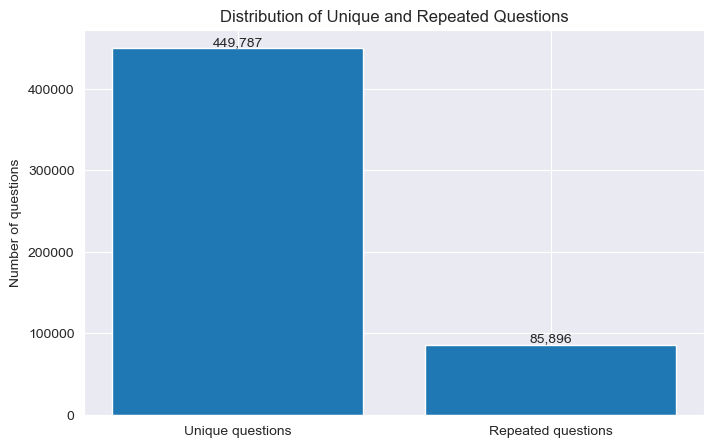

In [10]:
labels = ["Unique questions", "Repeated questions"]
values = [total_unique_questions, repeated_questions]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title("Distribution of Unique and Repeated Questions")
plt.ylabel("Number of questions")

for i, v in enumerate(values):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()


### Summary: Number of Unique Questions

The dataset contains 449,787 unique questions. Among them, 85,896 questions (approximately 19.10%) appear more than once in the dataset, indicating a non-negligible level of repetition.

The most frequent question occurs 122 times, which shows that while most questions are unique, a small subset of highly repeated questions exists. This pattern reflects realistic user behavior, where certain popular or generic questions are asked many times in slightly different contexts.

Overall, the presence of repeated questions justifies the relevance of the duplicate detection task and highlights the importance of handling redundancy in real-world text-based systems.


## Number of occurrences of each question

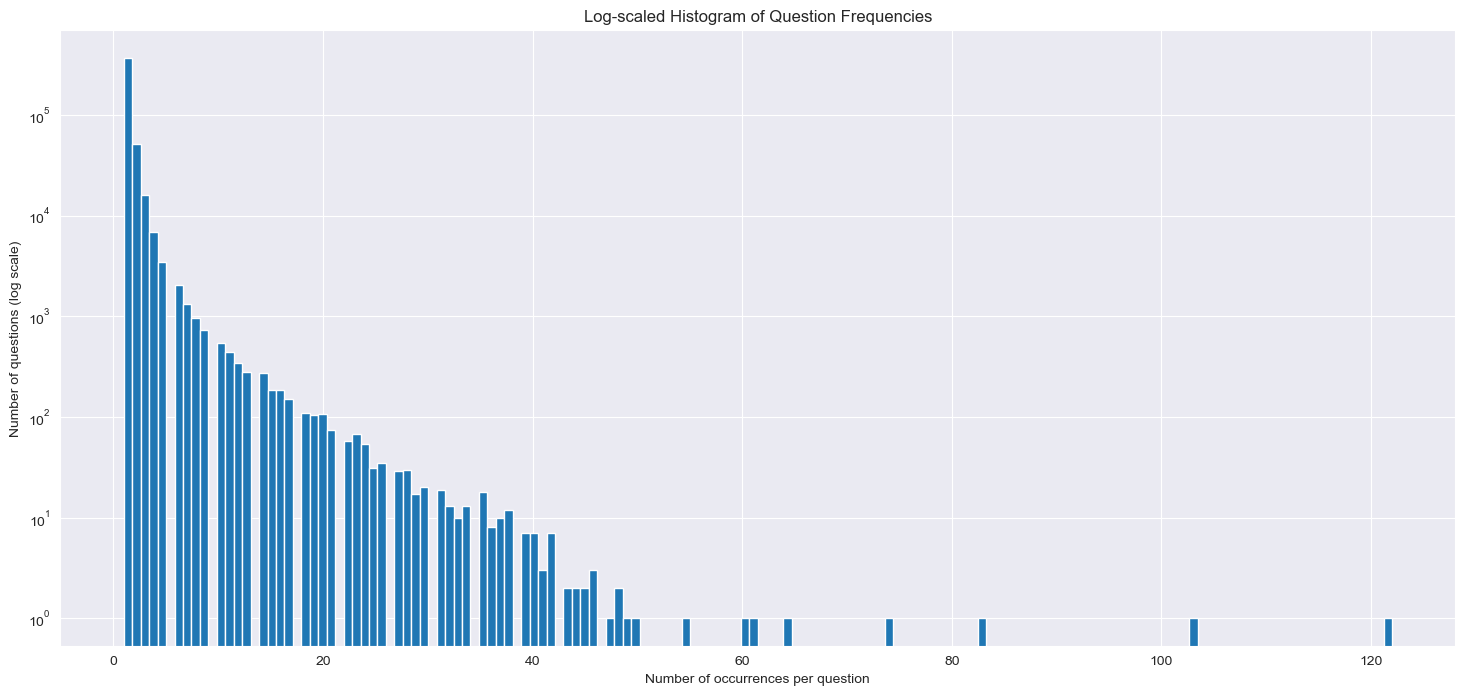

Maximum number of repetitions of a single question: 122


In [11]:
question_freq = qid_counts

max_freq = question_freq.max()

plt.figure(figsize=(18, 8))
plt.hist(question_freq, bins=150)
plt.yscale('log')
plt.title('Log-scaled Histogram of Question Frequencies')
plt.xlabel('Number of occurrences per question')
plt.ylabel('Number of questions (log scale)')

plt.show()

print(f"Maximum number of repetitions of a single question: {max_freq}")


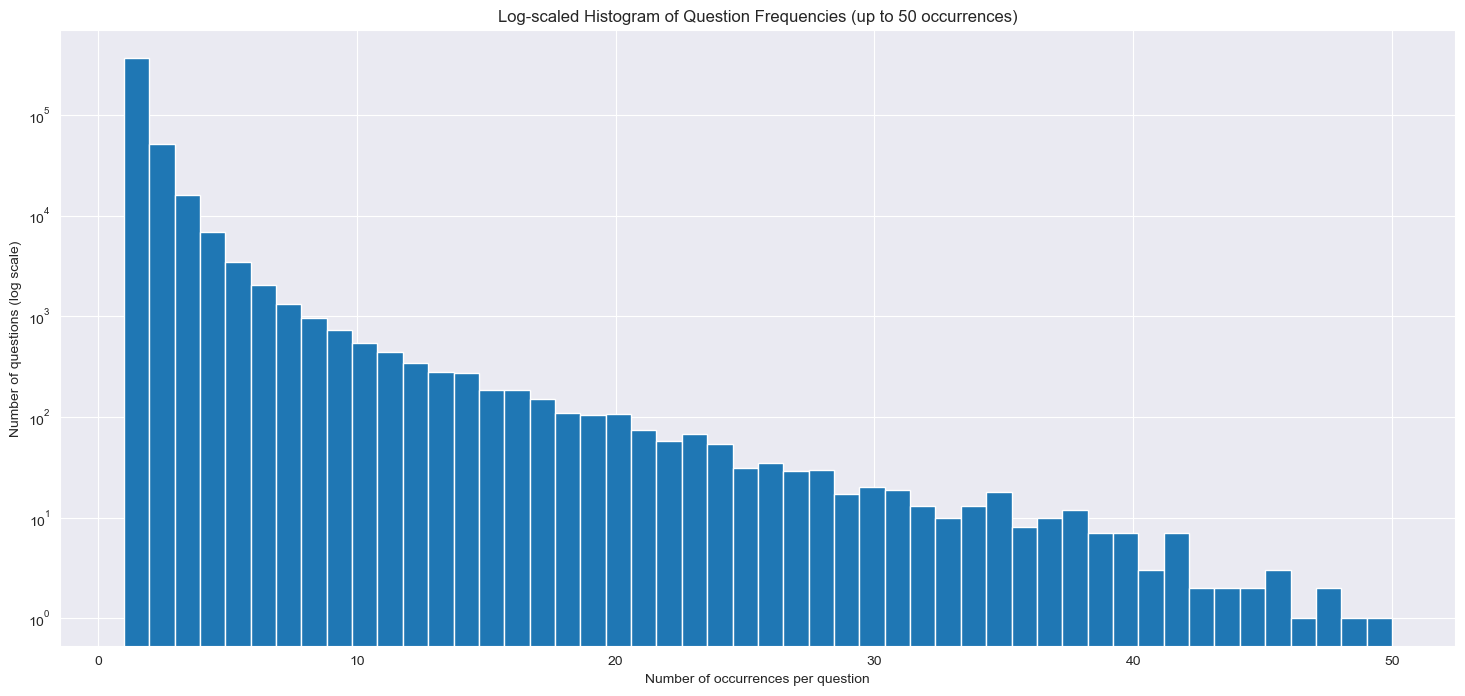

In [12]:
plt.figure(figsize=(18, 8))
plt.hist(question_freq[question_freq <= 50], bins=50)
plt.yscale('log')
plt.title('Log-scaled Histogram of Question Frequencies (up to 50 occurrences)')
plt.xlabel('Number of occurrences per question')
plt.ylabel('Number of questions (log scale)')
plt.show()


### Summary: Distribution of Question Frequencies

The distribution of question frequencies is highly right-skewed with a long tail. Most questions appear only once, while a small number of questions are repeated many times.

The full histogram shows that the maximum number of repetitions for a single question reaches 122, indicating the presence of a few extremely frequent questions. However, such cases are rare and represent only a very small fraction of the dataset.

The truncated histogram (limited to 50 occurrences) reveals that the vast majority of questions appear fewer than 10 times, and the number of questions decreases rapidly as the number of occurrences increases. This suggests that the dataset follows a typical long-tail distribution, where uniqueness dominates but repeated patterns still exist.

Overall, this structure reflects realistic user behavior and confirms the relevance of the duplicate detection task, as there is a significant amount of repetition, but it is concentrated in a small subset of popular or generic questions.


# Basic Feature Extraction

In [13]:
cache_path = processed_dir / "df_fe_without_preprocessing_train.csv"
cache_path.parent.mkdir(parents=True, exist_ok=True)

if cache_path.is_file():
    df = pd.read_csv(cache_path, encoding="latin-1")
else:
    df["freq_qid1"] = df.groupby("qid1")["qid1"].transform("size")
    df["freq_qid2"] = df.groupby("qid2")["qid2"].transform("size")

    df["q1len"] = df["question1"].astype(str).str.len()
    df["q2len"] = df["question2"].astype(str).str.len()

    df["q1_n_words"] = df["question1"].astype(str).str.split().str.len()
    df["q2_n_words"] = df["question2"].astype(str).str.split().str.len()

    def _token_set(text):
        return {w.strip().lower() for w in str(text).split() if w.strip()}

    q1_sets = df["question1"].map(_token_set)
    q2_sets = df["question2"].map(_token_set)

    common_words = q1_sets.combine(q2_sets, lambda a, b: len(a & b))
    total_words = q1_sets.combine(q2_sets, lambda a, b: len(a) + len(b))

    df["word_Common"] = common_words.astype(float)
    df["word_Total"] = total_words.astype(float)
    df["word_share"] = (df["word_Common"] / df["word_Total"]).fillna(0.0)

    df["freq_q1+q2"] = df["freq_qid1"] + df["freq_qid2"]
    df["freq_q1-q2"] = (df["freq_qid1"] - df["freq_qid2"]).abs()

    df.to_csv(cache_path, index=False)

df.head()


,id,qid1,qid2,question1,question2,is_duplicate,freq_qid1,freq_qid2,q1len,q2len,q1_n_words,q2_n_words,word_Common,word_Total,word_share,freq_q1+q2,freq_q1-q2
0,332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,1,1,47,81,9,14,1.0,21.0,0.047619,2,0
1,196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,1,1,62,55,9,8,4.0,15.0,0.266667,2,0
2,113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,1,1,32,78,5,15,1.0,18.0,0.055556,2,0
3,266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,3,6,51,42,11,9,6.0,20.0,0.300000,9,3
4,122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,17,27,159,68,31,11,7.0,40.0,0.175000,44,10


In [14]:
q1_min = df["q1_n_words"].min()
q2_min = df["q2_n_words"].min()

q1_min_cnt = (df["q1_n_words"] == q1_min).sum()
q2_min_cnt = (df["q2_n_words"] == q2_min).sum()

print(f"Minimum length of the questions in question1: {q1_min}")
print(f"Minimum length of the questions in question2: {q2_min}")
print(f"Number of Questions with minimum length [question1]: {q1_min_cnt}")
print(f"Number of Questions with minimum length [question2]: {q2_min_cnt}")


Minimum length of the questions in question1: 1
Minimum length of the questions in question2: 1
Number of Questions with minimum length [question1]: 62
Number of Questions with minimum length [question2]: 19


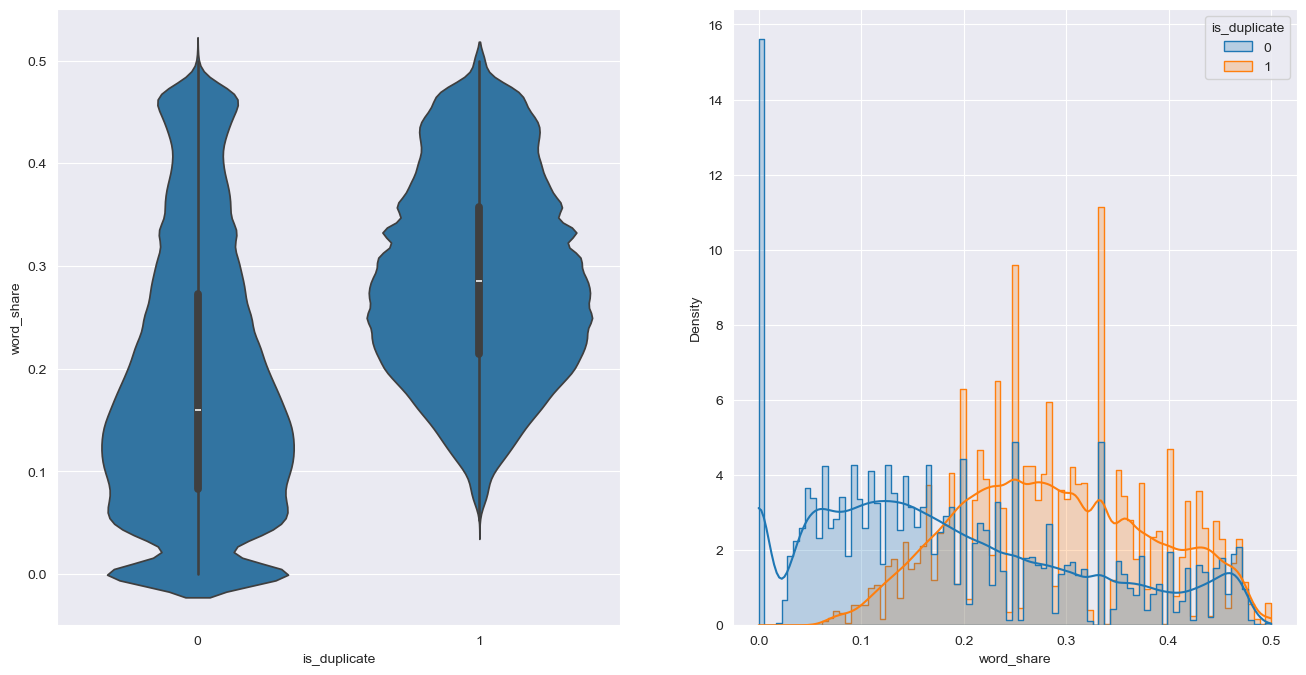

In [15]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sns.violinplot(x="is_duplicate", y="word_share", data=df)

plt.subplot(1, 2, 2)
sns.histplot(data=df, x="word_share", hue="is_duplicate", kde=True, element="step", stat="density", common_norm=False)

plt.show()


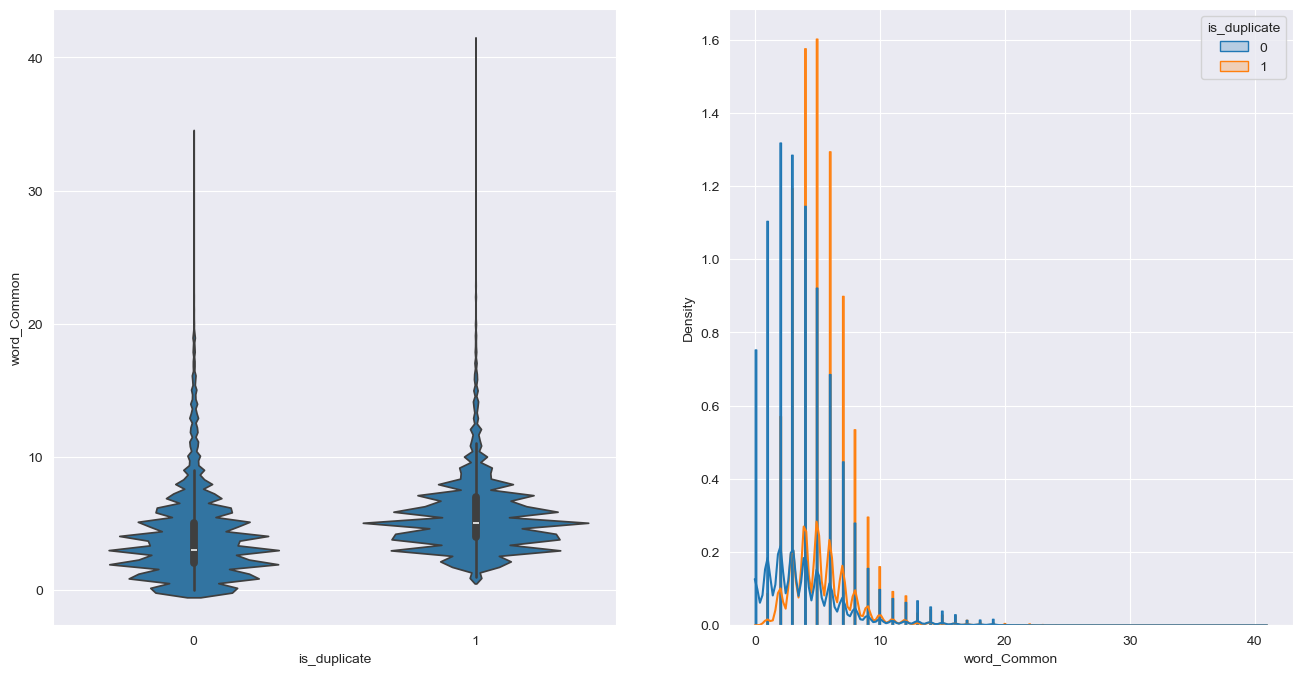

In [16]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sns.violinplot(x="is_duplicate", y="word_Common", data=df)

plt.subplot(1, 2, 2)
sns.histplot(data=df, x="word_Common", hue="is_duplicate", kde=True, element="step", stat="density", common_norm=False)

plt.show()


### Summary: Basic Feature Extraction

The minimum length of questions in both `question1` and `question2` is one word. However, such very short questions are relatively rare: only 62 cases for `question1` and 19 cases for `question2`. This indicates that the majority of questions contain more meaningful textual content.

The `word_share` feature shows a clear separation between duplicate and non-duplicate pairs. Duplicate question pairs (`is_duplicate = 1`) tend to have significantly higher word overlap ratios, while non-duplicate pairs are concentrated at lower `word_share` values. This confirms that lexical overlap is a strong indicator of semantic similarity.

Similarly, the `word_Common` feature demonstrates that duplicate pairs usually share more common words than non-duplicate pairs. While both distributions are right-skewed with long tails, the center of mass for duplicate pairs is shifted towards higher values.

Overall, these basic textual and frequency-based features capture meaningful differences between duplicate and non-duplicate question pairs and are therefore useful signals for building an effective classification model.


## Advanced Feature Extraction

In [17]:
df_nlp = build_nlp_features_train(project_root)
df_nlp.head(2)


,id,qid1,qid2,question1,question2,is_duplicate,cwc_min,cwc_max,csc_min,csc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,token_set_ratio,token_sort_ratio,fuzz_ratio,fuzz_partial_ratio,longest_substr_ratio
0,332278,459256,459257,the iliad and the odyssey in the greek culture,how do i prove that the pairs of three indepen...,0,0.000000,0.000000,0.333322,0.142855,...,0.071428,0.0,0.0,5.0,11.5,34,41,35,45,0.104167
1,196656,297402,297403,what is practical management and what is strat...,what are the practical aspects of strategic ma...,0,0.999967,0.749981,0.333322,0.249994,...,0.444440,1.0,1.0,1.0,8.5,91,75,71,67,0.392857


In [18]:
duplicate_df = df[df["is_duplicate"] == 1]
nonduplicate_df = df[df["is_duplicate"] == 0]

dup_questions = pd.concat([duplicate_df["question1"], duplicate_df["question2"]], ignore_index=True)
nondup_questions = pd.concat([nonduplicate_df["question1"], nonduplicate_df["question2"]], ignore_index=True)

print(f"Number of data points in class 1 (duplicate pairs): {len(dup_questions)}")
print(f"Number of data points in class 0 (non-duplicate pairs): {len(nondup_questions)}")

dup_questions.to_csv(processed_dir / "train_p.txt", index=False, header=False)
nondup_questions.to_csv(processed_dir / "train_n.txt", index=False, header=False)


Number of data points in class 1 (duplicate pairs): 238820
Number of data points in class 0 (non-duplicate pairs): 408038


In [19]:
text_dup = (processed_dir / "train_p.txt").read_text(encoding="utf-8", errors="ignore")
text_nondup = (processed_dir / "train_n.txt").read_text(encoding="utf-8", errors="ignore")

custom_stopwords = set(stopwords.words("english"))
custom_stopwords.update(["said", "br", " "])
custom_stopwords.difference_update({"not", "no", "like"})

print(f"Total number of characters in duplicate pair questions: {len(text_dup)}")
print(f"Total number of characters in non-duplicate pair questions: {len(text_nondup)}")


Total number of characters in duplicate pair questions: 12906672
Total number of characters in non-duplicate pair questions: 26632473


Word Cloud for Duplicate Question Pairs


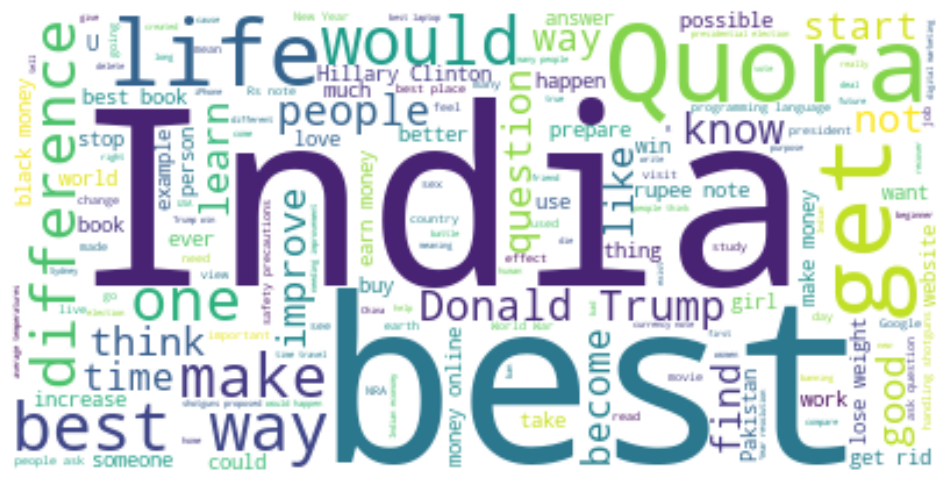

In [20]:
text_dup = (processed_dir / "train_p.txt").read_text(encoding="utf-8", errors="ignore")

custom_stopwords = set(stopwords.words("english"))
custom_stopwords.update(["said", "br", " "])
custom_stopwords.difference_update({"not", "no", "like"})

plt.figure(figsize=(12, 10))
wc = WordCloud(background_color="white", stopwords=custom_stopwords, max_words=200)
wc.generate(text_dup)

print("Word Cloud for Duplicate Question Pairs")
plt.imshow(wc.to_image(), interpolation="bilinear")
plt.axis("off")
plt.show()


Word Cloud for Non-Duplicate Question Pairs


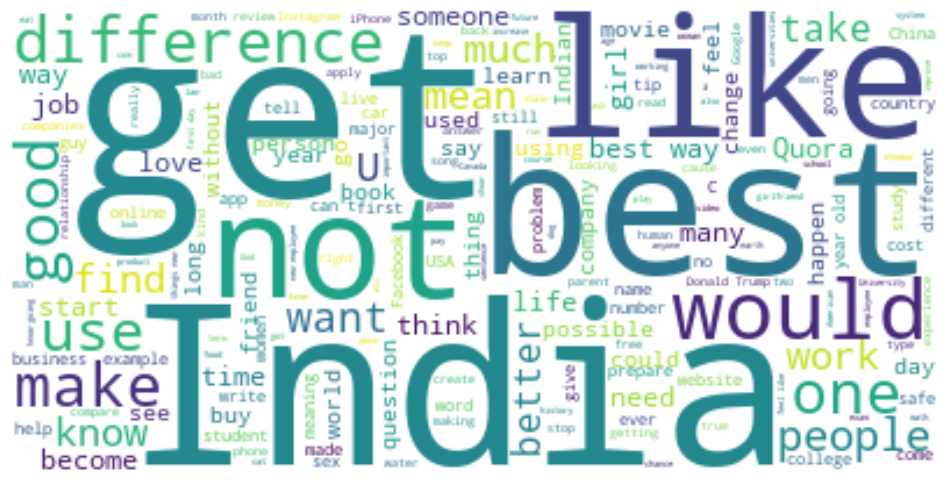

In [21]:
text_nondup = (processed_dir / "train_n.txt").read_text(encoding="utf-8", errors="ignore")

custom_stopwords = set(stopwords.words("english"))
custom_stopwords.update(["said", "br", " "])
custom_stopwords.difference_update({"not", "no", "like"})

plt.figure(figsize=(12, 10))
wc = WordCloud(background_color="white", stopwords=custom_stopwords, max_words=200)
wc.generate(text_nondup)

print("Word Cloud for Non-Duplicate Question Pairs")
plt.imshow(wc.to_image(), interpolation="bilinear")
plt.axis("off")
plt.show()


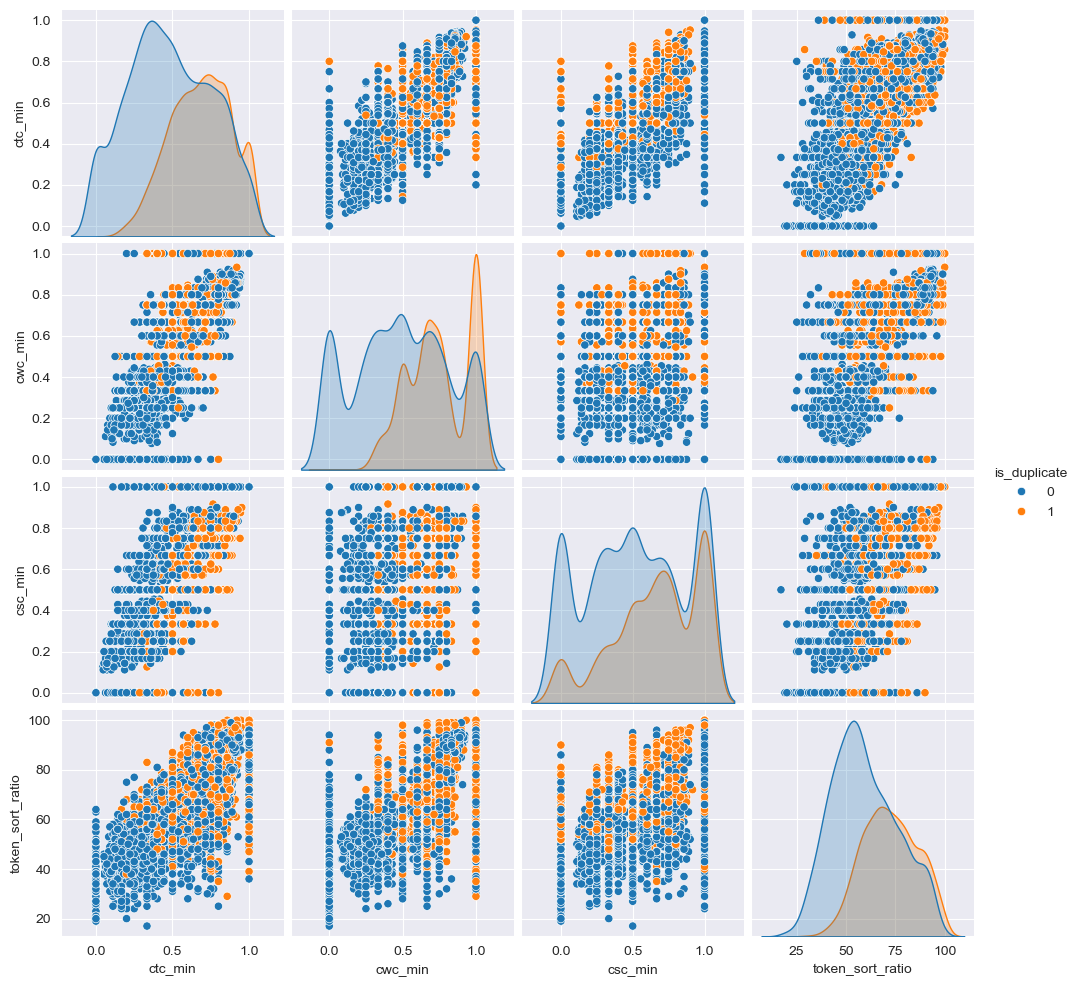

In [22]:
cols = ["ctc_min", "cwc_min", "csc_min", "token_sort_ratio", "is_duplicate"]
sample_df = df_nlp[cols].sample(n=min(5000, len(df_nlp)), random_state=42)

sns.pairplot(sample_df, hue="is_duplicate", vars=["ctc_min", "cwc_min", "csc_min", "token_sort_ratio"])
plt.show()


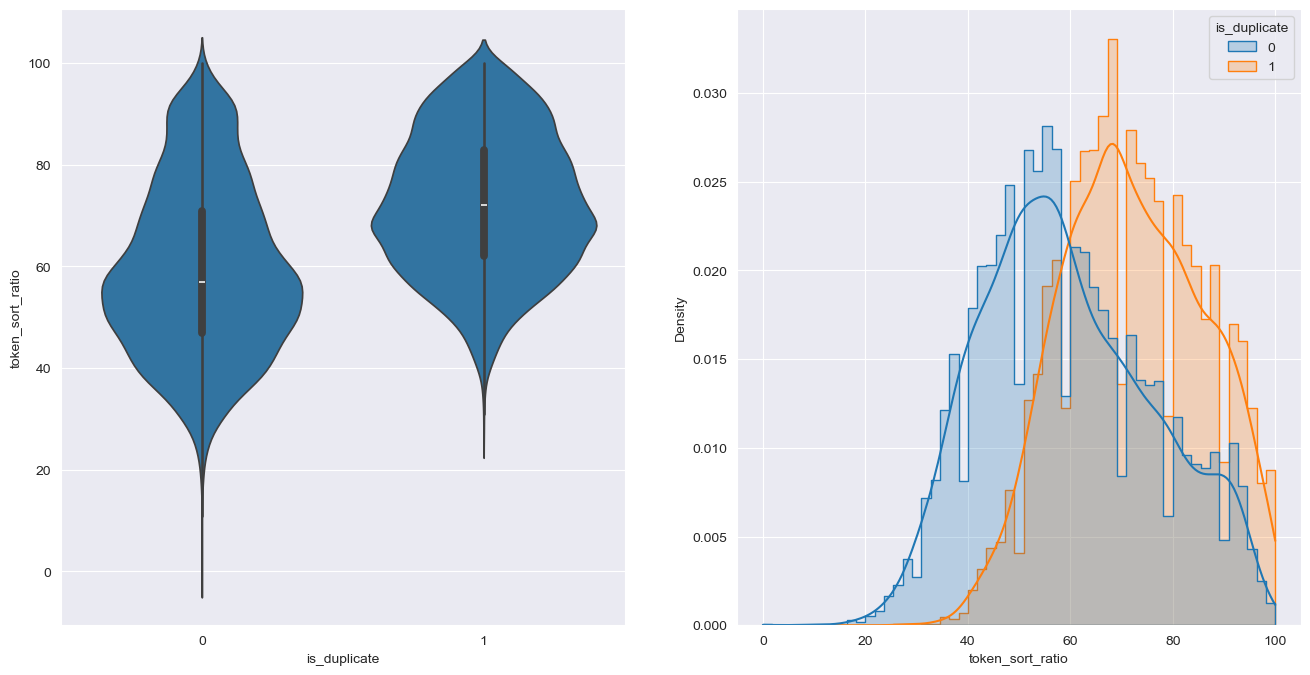

In [23]:
plot_cols = ["is_duplicate", "token_sort_ratio"]
plot_df = df_nlp[plot_cols].dropna().sample(n=min(20000, len(df_nlp)), random_state=42)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sns.violinplot(x="is_duplicate", y="token_sort_ratio", data=plot_df)

plt.subplot(1, 2, 2)
sns.histplot(data=plot_df, x="token_sort_ratio", hue="is_duplicate", kde=True, element="step", stat="density", common_norm=False)

plt.show()


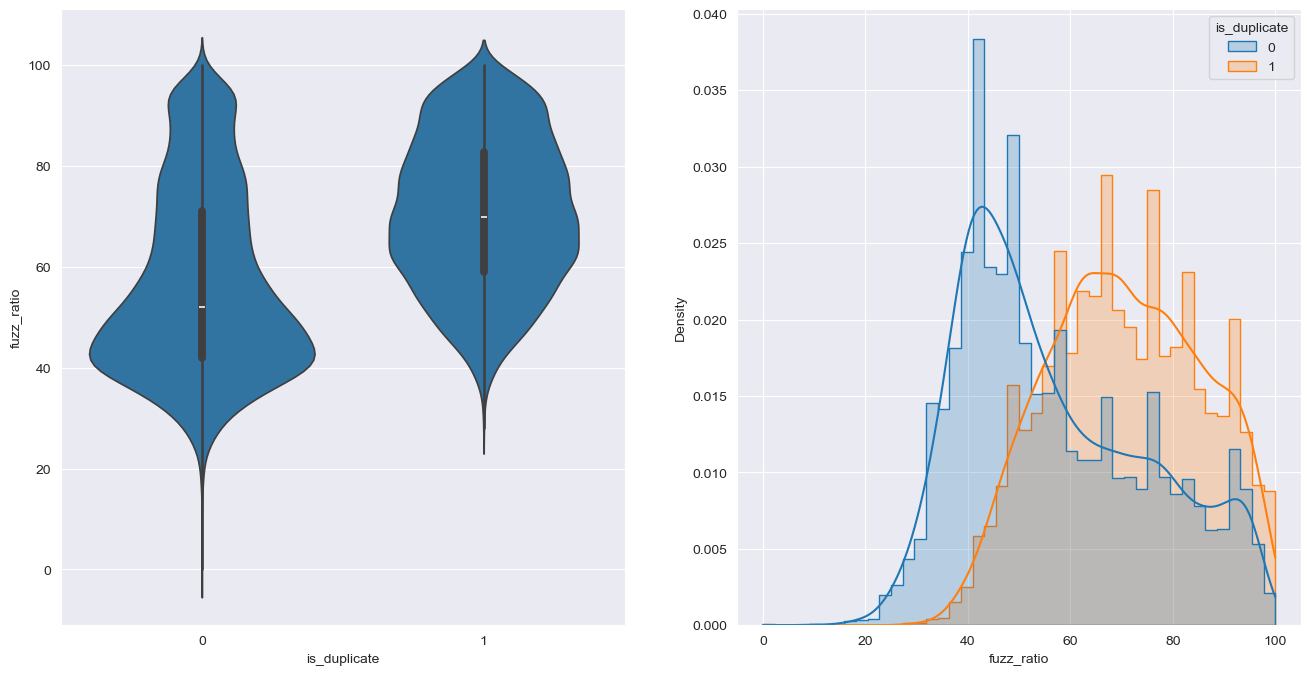

In [24]:
plot_cols = ["is_duplicate", "fuzz_ratio"]
plot_df = df_nlp[plot_cols].dropna().sample(n=min(20000, len(df_nlp)), random_state=42)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sns.violinplot(x="is_duplicate", y="fuzz_ratio", data=plot_df)

plt.subplot(1, 2, 2)
sns.histplot(data=plot_df, x="fuzz_ratio", hue="is_duplicate", kde=True, element="step", stat="density", common_norm=False)

plt.show()


In [25]:
feature_cols = [
    "ctc_min", "cwc_min", "csc_min",
    "token_sort_ratio", "fuzz_ratio",
    "abs_len_diff", "mean_len",
    "token_set_ratio", "fuzz_partial_ratio", "longest_substr_ratio"
]

tsne_sample = df_nlp[feature_cols + ["is_duplicate"]].dropna().sample(
    n=min(6000, len(df_nlp)),
    random_state=42
)

X = tsne_sample[feature_cols].to_numpy()
y = tsne_sample["is_duplicate"].to_numpy()

tsne3d = TSNE(
    n_components=3,
    init="pca",
    random_state=42,
    method="barnes_hut",
    angle=0.5,
    learning_rate="auto",
    perplexity=30,
    max_iter=1000,
    verbose=1
).fit_transform(X)




[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6000 samples in 0.011s...
[t-SNE] Computed neighbors for 6000 samples in 0.158s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6000
[t-SNE] Computed conditional probabilities for sample 2000 / 6000
[t-SNE] Computed conditional probabilities for sample 3000 / 6000
[t-SNE] Computed conditional probabilities for sample 4000 / 6000
[t-SNE] Computed conditional probabilities for sample 5000 / 6000
[t-SNE] Computed conditional probabilities for sample 6000 / 6000
[t-SNE] Mean sigma: 3.226832
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.855179
[t-SNE] KL divergence after 1000 iterations: 1.192735


In [26]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=tsne3d[:, 0],
            y=tsne3d[:, 1],
            z=tsne3d[:, 2],
            mode="markers",
            marker=dict(
                size=3,
                opacity=0.7,
                color=y,
                colorbar=dict(title="is_duplicate")
            )
        )
    ],
    layout=go.Layout(
        title="t-SNE 3D (advanced engineered features)",
        height=800,
        width=900
    )
)

fig.write_html(tsne_3d_html_path, include_plotlyjs="cdn")
fig.show()



In [27]:
mask_dup = (y == 1)
mask_nondup = (y == 0)

fig_classes = go.Figure(
    data=[
        go.Scatter3d(
            x=tsne3d[mask_nondup, 0],
            y=tsne3d[mask_nondup, 1],
            z=tsne3d[mask_nondup, 2],
            mode="markers",
            name="non-duplicate (0)",
            marker=dict(size=3, opacity=0.6)
        ),
        go.Scatter3d(
            x=tsne3d[mask_dup, 0],
            y=tsne3d[mask_dup, 1],
            z=tsne3d[mask_dup, 2],
            mode="markers",
            name="duplicate (1)",
            marker=dict(size=3, opacity=0.6)
        )
    ],
    layout=go.Layout(
        title="t-SNE 3D (advanced features) - separate traces by class",
        height=800,
        width=900
    )
)

fig_classes.write_html(reports_dir / "tsne_3d_engineered_features_by_class.html", include_plotlyjs="cdn")
fig_classes.show()



### Summary: Advanced Feature Extraction

The advanced feature extraction stage produced a set of informative lexical-similarity features, combining token-overlap statistics (e.g., common word/token ratios, length differences, first/last token match) with fuzzy string matching scores (e.g., token sort/set ratios, partial ratios, longest common substring). Together, these features capture both *structural overlap* (shared tokens / stopwords) and *approximate phrasing similarity* (reordered or partially matching text).

The dataset contains **238,820 duplicate pairs** and **408,038 non-duplicate pairs**, which indicates a moderate class imbalance toward the non-duplicate class. In terms of raw text volume, non-duplicate pairs also contain a substantially larger amount of text (**26,632,473** characters vs. **12,906,672** characters), suggesting that non-duplicate questions are, on average, longer and/or more diverse in wording.

The Word Cloud visualizations show that both classes share many common functional and generic words (e.g., *best*, *get*, *people*, *India*, *Quora*), but their relative prominence differs. Duplicate pairs tend to emphasize repetitive “how-to / best-way” style patterns, while non-duplicate pairs show broader topical diversity.

The pairwise feature plots and the violin/distribution plots (e.g., `token_sort_ratio`, `fuzz_ratio`) show a consistent shift toward higher similarity values for duplicates, while non-duplicates are more spread out and generally concentrated at lower similarity. Although the distributions overlap (as expected for paraphrases and tricky negatives), the separation is strong enough to provide meaningful signal for downstream classifiers.

To qualitatively inspect separability in feature space, we applied **3D t-SNE** on a **6,000-sample subset** of the engineered feature matrix. The optimization converged from a high initial divergence after early exaggeration (**KL ≈ 75.86 at 250 iterations**) down to a much lower value by the end (**KL ≈ 1.19 at 1000 iterations**). This indicates that the embedding stabilized and preserved local neighborhood structure well enough for visualization. The resulting interactive 3D plots were exported to HTML for reproducibility and convenient inspection on GitHub (see saved artifacts). :contentReference[oaicite:0]{index=0} :contentReference[oaicite:1]{index=1}

Overall, the advanced engineered features provide a strong, interpretable representation of question-pair similarity and should serve as a solid baseline for classical ML models (e.g., logistic regression, tree-based methods) and as complementary signals alongside embedding-based approaches.
